# **RUMAKU BUSINESS ANALYSIS**
## **EXECUTIVE SUMMARY**
This analysis investigates the decline in Rumaku's profitability despite changes in sales performance.

Key findings:

- Net profit declined by **65.94% in Q3 2025** compared with Q2 2025.
- Revenue declined by **59.72%**, indicating a major reduction in sales performance.
- **Kasur & Springbed, Pencahayaan, and Lemari & Rak** contributed approximately **85.6%** of the total profit decline.
- The Online channel remained profitable after shipping costs, but its profit margin declined from **39.39% to 30.11%**.
- Average discount increased from **8.19% to 8.74%**, indicating potential margin pressure.

### **BUSINESS RECOMMENDATION**

Focus on the three most affected product categories, improve Online channel economics, and use targeted rather than broad discounting to protect both margin and sales volume.

### **BUSINESS PROBLEM**
The meeting that prompted this analysis

Head of Retail, early January 2026
"Fourth-quarter sales were up, which is great. However, our profits actually fell, and I can't explain why to the board. Please find out what’s really going on and give me something I can base a decision on by next week."

Five follow-up questions we formulated
1. What was the magnitude of the profit decline, and in exactly which quarter did it occur?
2. Was the cause the product mix, sales channels, or discount policies?
3. Which categories were most affected, and what was their contribution?
4. Did the online channel remain profitable after accounting for shipping costs?
5. What action would most quickly restore margins without killing sales volume?

#**DATA LOADING AND MERGING DATASET**

In [ ]:
#Import, Load, and Merge Data CSV
import pandas as pd
import numpy as np

product = pd.read_csv("/content/drive/MyDrive/SEARA PERT 6/produk.csv")
transaction = pd.read_csv("/content/drive/MyDrive/SEARA PERT 6/transaksi.csv")

#Merge dataset transaction and product
transaction_product = transaction.merge(product,on="product_id",how="left")

The transaction and product datasets were successfully integrated using product_id, creating a transaction-level dataset enriched with product attributes such as category, brand, and pricing information.

## **Dataset Overview**

The dataset consists of transaction-level sales data combined with product information.

The transaction and product datasets were merged using `product_id`.

The analysis covers transactions from 2024 to 2025 and includes information about:

- Order date
- Customer
- Product
- Category
- Brand
- Sales channel
- Payment method
- Quantity
- Pricing
- Discount
- Cost
- Shipping cost

# **DATA CLEANING**

In [ ]:
# Check missing values, and remove exact duplicates
duplicate_count = transaction_product.duplicated().sum()
print("Duplicate before cleaning:", duplicate_count)
transaction_product = transaction_product.drop_duplicates()

print("\nDuplicate rows:")
print(transaction_product.duplicated().sum())

print("\nMissing values:")
print(transaction_product.isnull().sum())

transaction_product.info()

Duplicate before cleaning: 180

Duplicate rows:
0

Missing values:
order_id            0
order_date          0
customer_id         0
product_id          0
store_id          240
channel             0
qty                 0
unit_price          0
discount_pct      845
shipping_cost     578
payment_method    351
order_status        0
product_name        0
category            0
sub_category        0
brand             432
list_price          0
cost_price        963
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 12060 entries, 0 to 12239
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        12060 non-null  object 
 1   order_date      12060 non-null  object 
 2   customer_id     12060 non-null  object 
 3   product_id      12060 non-null  object 
 4   store_id        11820 non-null  object 
 5   channel         12060 non-null  object 
 6   qty             12060 non-null  int64  
 7   unit_price

The initial data-quality check helps identify missing values and duplicate records that could affect key business metrics such as revenue, order count, and profit. Removing exact duplicates ensures each transaction is counted only once.

In [ ]:
#CHANGE WRONG DATA TYPE
# Convert mixed date formats
transaction_product["order_date"] = (
    transaction_product["order_date"]
    .astype(str)
    .str.replace("-", "/", regex=False)
)

transaction_product["order_date"] = pd.to_datetime(
    transaction_product["order_date"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

# Convert unit_price to numeric
transaction_product["unit_price"] = pd.to_numeric(
    transaction_product["unit_price"],
    errors="coerce"
)

# Check result
print("Invalid dates:", transaction_product["order_date"].isna().sum())
print("Invalid unit price:", transaction_product["unit_price"].isna().sum())

Invalid dates: 0
Invalid unit price: 1069


The dataset contained inconsistent date formats and non-numeric unit_price values. Standardizing these fields ensures accurate time-series analysis and financial calculations. Converting order_date to datetime enables reliable monthly and quarterly analysis, while converting unit_price to numeric ensures accurate revenue calculations.

In [ ]:
# CLEANING PAYMENT METHOD

transaction_product["payment_method"] = (
    transaction_product["payment_method"]
    .str.strip()
    .str.title()
    .replace({
        "Tunai": "Cash",
        "Ewallet": "E-Wallet",
        "E Wallet": "E-Wallet",
        "Cicilan 0 %": "Cicilan 0%",
        "Cash On Delivery": "COD",
        "Kartu Kredit": "Credit Card",
        "Transfer": "Transfer Bank"
    })
    .fillna("Unknown")
)

display(transaction_product["payment_method"].value_counts())

,count
payment_method,
Transfer Bank,3280
E-Wallet,2566
Credit Card,2289
Cicilan 0%,1553
Cash,1154
Cod,769
Unknown,351
COD,98


Different payment method labels were standardized into consistent categories such as Cash, E-Wallet, COD, Credit Card, and Bank Transfer. This ensures each payment method is counted correctly and provides more accurate customer behavior analysis.

In [ ]:
# CLEANING BRAND & CHANNEL

transaction_product["brand"] = (
    transaction_product["brand"]
    .fillna("Unknown")
)

transaction_product["channel"] = (
    transaction_product["channel"]
    .str.strip()
    .str.title()
)

# Check result
print("Brand:")
display(transaction_product["brand"].value_counts(dropna=False))

print("\nChannel:")
display(transaction_product["channel"].value_counts(dropna=False))

Brand:


,count
brand,
Rumaku Signature,2371
Sentra Jaya,2341
Ombak Living,2100
Nordika,1831
Kayana,1532
Alunan,1453
Unknown,432



Channel:


,count
channel,
Online,7048
Offline,4638
Toko Fisik,374


Brand and channel fields were standardized to ensure consistent categories and accurate performance analysis. This is especially important when comparing the profitability of Online and physical-store channels.

In [ ]:
# CLEANING STORE_ID
display(
    transaction_product.loc[
        transaction_product["store_id"].isna(),
        "channel"
    ].value_counts()
)

# Missing store_id cannot be reliably inferred
transaction_product["store_id"] = (
    transaction_product["store_id"]
    .fillna("Unknown")
)

# Check result
print("Missing store_id:", transaction_product["store_id"].isna().sum())



,count
channel,
Online,138
Offline,101
Toko Fisik,1


Missing store_id: 0


Missing store_id values were labeled as Unknown because they could not be reliably determined. This avoids incorrect store assignments and ensures more accurate store-level analysis.

In [ ]:
# CLEANING DISCOUNT
# Missing discount = 0
transaction_product["discount_pct"] = (
    transaction_product["discount_pct"].fillna(0)
)

# Check invalid values
invalid_discount = (
    (transaction_product["discount_pct"] < 0) |
    (transaction_product["discount_pct"] > 100)
)

print("Missing discount:", transaction_product["discount_pct"].isna().sum())
print("Invalid discount:", invalid_discount.sum())


Missing discount: 0
Invalid discount: 0


Missing discount values were treated as zero, while values outside the 0–100% range were considered invalid. Since discounts affect selling prices and profitability, accurate discount data is important for reliable revenue and margin analysis.

In [ ]:
# CLEANING SHIPPING COST
# 1. Toko Fisik do not have shipping costs.
transaction_product.loc[
    transaction_product["channel"] == "Toko Fisik",
    "shipping_cost"
] = transaction_product.loc[
    transaction_product["channel"] == "Toko Fisik",
    "shipping_cost"
].fillna(0)

# 2. Missing shipping cost → median based on channel
transaction_product["shipping_cost"] = (
    transaction_product.groupby("channel")["shipping_cost"]
    .transform(lambda x: x.fillna(x.median()))
)

# 3. Check missing values
print(
    "Missing shipping_cost:",
    transaction_product["shipping_cost"].isna().sum()
)


Missing shipping_cost: 0


Missing shipping costs were handled based on the sales channel. Physical-store transactions were assigned zero, while missing costs in other channels were filled using the channel median. This approach reflects differences in shipping costs between Online and physical stores.

In [ ]:
# CHECK SHIPPING COST OUTLIERS

Q1 = transaction_product["shipping_cost"].quantile(0.25)
Q3 = transaction_product["shipping_cost"].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

outlier = transaction_product[
    transaction_product["shipping_cost"] > upper_bound
]

print("Number of outliers:", len(outlier))

display(
    outlier[
        ["order_id", "channel", "qty", "unit_price", "shipping_cost"]
    ].sort_values(
        "shipping_cost",
        ascending=False
    ).head(10)
)

Number of outliers: 6


,order_id,channel,qty,unit_price,shipping_cost
5495,ORD111108,Offline,1,15052000.0,38701491.0
7418,ORD102553,Offline,1,NaN,35182402.0
5142,ORD108774,Offline,1,417000.0,34520246.0
7782,ORD104723,Online,1,1090000.0,22658337.0
4153,ORD103050,Offline,1,427000.0,18117287.0
4800,ORD106107,Offline,1,1082000.0,15466398.0


Potentially abnormal shipping costs were identified using the IQR method. These values were not automatically removed because high shipping costs may represent valid transactions. Outlier detection was used for further investigation rather than automatic deletion.

In [ ]:
# CLEANING COST PRICE
# Fill missing cost_price with category median
transaction_product["cost_price"] = (
    transaction_product["cost_price"]
    .fillna(
        transaction_product.groupby("category")["cost_price"]
        .transform("median")
    )
)

# Check missing values
print(
    "Missing cost_price:",
    transaction_product["cost_price"].isna().sum()
)

# Check invalid values
print(
    "Invalid cost_price:",
    (transaction_product["cost_price"] <= 0).sum()
)

Missing cost_price: 0
Invalid cost_price: 0


Missing cost_price values were filled using the median cost within each product category. This preserves the data while reflecting differences in product costs across categories.

In [ ]:
# CLEANING UNIT PRICE

# Fill missing unit_price using list_price and discount
missing = transaction_product["unit_price"].isna()

transaction_product.loc[missing, "unit_price"] = (
    transaction_product.loc[missing, "list_price"] *
    (1 - transaction_product.loc[missing, "discount_pct"] / 100)
)

# Check result
print(
    "Missing unit_price:",
    transaction_product["unit_price"].isna().sum()
)

Missing unit_price: 0


Missing selling prices were calculated using list price and discount percentage. This keeps incomplete transactions available for revenue and profitability analysis while following the dataset’s pricing logic.

The Formula:

Unit Price = List Price × (1 − Discount %)

| Column           | Treatment                            | Reason                         |
| ---------------- | ------------------------------------ | ------------------------------ |
| `order_date`     | Convert to datetime                  | Standardize date format        |
| `payment_method` | Standardize labels                   | Remove inconsistent categories |
| `brand`          | Missing → Unknown                    | Cannot reliably infer          |
| `store_id`       | Missing → Unknown                    | Cannot reliably infer          |
| `discount_pct`   | Missing → 0                          | Represent no recorded discount |
| `cost_price`     | Category median                      | Preserve transaction records   |
| `unit_price`     | Calculate from list price & discount | Recover missing values         |
| `shipping_cost`  | Channel-based treatment              | Reflect business logic         |


The cleaning process used business rules based on the meaning of each variable. This shows that data cleaning is not just about removing missing values, but also about understanding the business context.

# **DATA VALIDATION**
After data cleaning, the dataset requires a final validation step to ensure that duplicate records, missing values, and incorrect data types have been appropriately addressed before calculating financial metrics.

In [ ]:
# FINAL VALIDATION

print("Rows:", len(transaction_product))
print("Duplicate rows:", transaction_product.duplicated().sum())

print("\nMissing values:")
print(transaction_product.isnull().sum())

print("\nData types:")
transaction_product.info()

Rows: 12060
Duplicate rows: 0

Missing values:
order_id          0
order_date        0
customer_id       0
product_id        0
store_id          0
channel           0
qty               0
unit_price        0
discount_pct      0
shipping_cost     0
payment_method    0
order_status      0
product_name      0
category          0
sub_category      0
brand             0
list_price        0
cost_price        0
dtype: int64

Data types:
<class 'pandas.core.frame.DataFrame'>
Index: 12060 entries, 0 to 12239
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        12060 non-null  object        
 1   order_date      12060 non-null  datetime64[ns]
 2   customer_id     12060 non-null  object        
 3   product_id      12060 non-null  object        
 4   store_id        12060 non-null  object        
 5   channel         12060 non-null  object        
 6   qty             12060 non-null  int64     

The final validation ensures that the cleaned dataset is ready for business analysis. Completeness, uniqueness, and data types were checked before using the data for financial analysis.

# **CALCULATE BUSINESS METRICS**
The next stage converts cleaned transaction data into business metrics to measure financial performance. This shifts the analysis from “Is the data correct?” to “What is happening to the business?”

In [ ]:
#Create the final dataset for matrix analysis
transaction_sales = transaction_product.copy()

transaction_sales["revenue"] = (
    transaction_sales["qty"] *
    transaction_sales["unit_price"])

transaction_sales["total_cost"] = (
    transaction_sales["qty"] *
    transaction_sales["cost_price"])

transaction_sales["gross_profit"] = (
    transaction_sales["revenue"] -
    transaction_sales["total_cost"])

transaction_sales["net_profit"] = (
    transaction_sales["gross_profit"] -
    transaction_sales["shipping_cost"])

transaction_sales["quarter"] = (
    transaction_sales["order_date"]
    .dt.to_period("Q")
    .astype(str))

transaction_sales["quarter"].value_counts().sort_index()

,count
quarter,
2024Q1,1219
2024Q2,1397
2024Q3,1128
2024Q4,1566
2025Q1,1603
2025Q2,1747
2025Q3,1398
2025Q4,2002


The analysis separates revenue, product costs, shipping costs, gross profit, and net profit to identify the main causes of profitability changes. A decline in net profit may result from lower revenue, higher costs, or lower product margins.

In [ ]:
#Quarter analysis
quarterly = (
    transaction_sales
    .groupby("quarter")
    .agg(
        revenue=("revenue", "sum"),
        gross_profit=("gross_profit", "sum"),
        shipping_cost=("shipping_cost", "sum"),
        net_profit=("net_profit", "sum")
    )
    .reset_index()
)

quarterly["profit_margin"] = (
    quarterly["net_profit"] /
    quarterly["revenue"] * 100
)

display(quarterly)

,quarter,revenue,gross_profit,shipping_cost,net_profit,profit_margin
0,2024Q1,7.601812e+09,2.627892e+09,210618000.0,2.417274e+09,31.798658
1,2024Q2,7.113028e+09,2.493220e+09,219217000.0,2.274002e+09,31.969540
2,2024Q3,5.976164e+09,2.692178e+09,177896000.0,2.514282e+09,42.071849
3,2024Q4,1.233737e+10,5.110700e+09,283799685.0,4.826900e+09,39.124212
4,2025Q1,9.876061e+09,3.623653e+09,328188648.0,3.295464e+09,33.368206
5,2025Q2,1.600391e+10,6.426748e+09,280195000.0,6.146552e+09,38.406571
6,2025Q3,6.446914e+09,2.365754e+09,271942491.0,2.093812e+09,32.477743
7,2025Q4,1.535539e+10,7.159048e+09,353523337.0,6.805525e+09,44.320110


Quarterly aggregation shows how revenue and profitability evolve over time and provides the foundation for identifying when the business performance deteriorated.

Q3 2025 experienced the most significant deterioration in profitability, with net profit declining by 65.94% compared with Q2 2025.

# **KPI OVERVIEW**
The KPI overview provides a high-level view of business performance. Revenue measures business scale, net profit shows total profitability, profit margin measures profitability efficiency, and total orders reflects sales activity.

In [ ]:
# KPI Overview

total_revenue = transaction_sales["revenue"].sum()
total_net_profit = transaction_sales["net_profit"].sum()
profit_margin = total_net_profit / total_revenue * 100
total_orders = transaction_sales["order_id"].nunique()

print(f"Total Revenue    : Rp {total_revenue:,.0f}")
print(f"Total Net Profit : Rp {total_net_profit:,.0f}")
print(f"Profit Margin    : {profit_margin:.2f}%")
print(f"Total Orders     : {total_orders:,}")

Total Revenue    : Rp 80,710,649,504
Total Net Profit : Rp 30,373,813,343
Profit Margin    : 37.63%
Total Orders     : 12,000


The overall business performance is summarized through total revenue, net profit, profit margin, and total orders.

# **BUSINESS ANALYSIS**

## **1. What is the magnitude of the profit decline, and in which quarters did this trend persist?**

In [ ]:
quarterly["profit_change"] = (
    quarterly["net_profit"].pct_change() * 100
)

display(quarterly)

,quarter,revenue,gross_profit,shipping_cost,net_profit,profit_margin,profit_change
0,2024Q1,7.601812e+09,2.627892e+09,210618000.0,2.417274e+09,31.798658,NaN
1,2024Q2,7.113028e+09,2.493220e+09,219217000.0,2.274002e+09,31.969540,-5.926996
2,2024Q3,5.976164e+09,2.692178e+09,177896000.0,2.514282e+09,42.071849,10.566391
3,2024Q4,1.233737e+10,5.110700e+09,283799685.0,4.826900e+09,39.124212,91.979235
4,2025Q1,9.876061e+09,3.623653e+09,328188648.0,3.295464e+09,33.368206,-31.727110
5,2025Q2,1.600391e+10,6.426748e+09,280195000.0,6.146552e+09,38.406571,86.515521
6,2025Q3,6.446914e+09,2.365754e+09,271942491.0,2.093812e+09,32.477743,-65.935181
7,2025Q4,1.535539e+10,7.159048e+09,353523337.0,6.805525e+09,44.320110,225.030370


Quarter-over-quarter analysis shows that the largest decline occurred in Q3 2025. This suggests that management should investigate both lower revenue and margin pressure.

Net profit declined by 65.94% from Q2 2025 to Q3 2025, making Q3 2025 the critical period requiring management investigation.

## **2. Is it driven by the product mix, sales channels, or discount policies?**

In [ ]:
#Analysis by product category
category_analysis = (
    transaction_sales
    .groupby(["quarter", "category"])
    .agg(
        revenue=("revenue", "sum"),
        net_profit=("net_profit", "sum")
    )
    .reset_index()
)

display(category_analysis)

,quarter,category,revenue,net_profit
0,2024Q1,Dekorasi,1.139135e+08,34190500.0
1,2024Q1,Kasur & Springbed,1.343624e+09,456731500.0
2,2024Q1,Lemari & Rak,7.870405e+08,237561500.0
3,2024Q1,Meja,8.975618e+08,251300750.0
4,2024Q1,Pencahayaan,3.649938e+08,69045750.0
...,...,...,...,...
59,2025Q4,Meja,1.256046e+09,314180913.0
60,2025Q4,Pencahayaan,6.221145e+08,115849501.0
61,2025Q4,Peralatan Dapur,4.338538e+08,72986750.0
62,2025Q4,Sofa & Kursi,2.415547e+09,741295000.0


Category-level analysis shows which product categories contributed to the overall profit decline. This helps determine whether the decline affected all categories or only specific ones.

In [ ]:
#Analysis by channel
channel_analysis = (
    transaction_sales
    .groupby(["quarter", "channel"])
    .agg(
        revenue=("revenue", "sum"),
        net_profit=("net_profit", "sum"),
        shipping_cost=("shipping_cost", "sum")
    )
    .reset_index()
)

display(channel_analysis)

,quarter,channel,revenue,net_profit,shipping_cost
0,2024Q1,Offline,2.792667e+09,9.195880e+08,0.0
1,2024Q1,Online,4.687785e+09,1.457212e+09,210618000.0
2,2024Q1,Toko Fisik,1.213600e+08,4.047400e+07,0.0
3,2024Q2,Offline,2.581334e+09,9.189588e+08,0.0
4,2024Q2,Online,4.330605e+09,1.286346e+09,219217000.0
5,2024Q2,Toko Fisik,2.010900e+08,6.869800e+07,0.0
6,2024Q3,Offline,2.916040e+09,1.641994e+09,0.0
7,2024Q3,Online,2.886122e+09,8.195258e+08,177896000.0
8,2024Q3,Toko Fisik,1.740012e+08,5.276225e+07,0.0
9,2024Q4,Offline,4.621868e+09,2.819258e+09,33583685.0


Channel-level analysis compares revenue, net profit, and shipping costs across sales channels. This helps identify whether profit declines are linked to a specific channel, especially whether Online sales remain profitable after shipping costs.

In [ ]:
#Analysis by discount
discount_analysis = (
    transaction_sales
    .groupby(["quarter", "discount_pct"])
    .agg(
        revenue=("revenue", "sum"),
        net_profit=("net_profit", "sum")
    )
    .reset_index()
)

display(discount_analysis)

,quarter,discount_pct,revenue,net_profit
0,2024Q1,0.0,1.811179e+09,5.890210e+08
1,2024Q1,5.0,9.615162e+08,3.047042e+08
2,2024Q1,10.0,9.187390e+08,2.758430e+08
3,2024Q1,15.0,1.269665e+09,3.139652e+08
4,2024Q1,20.0,2.203070e+09,8.267380e+08
...,...,...,...,...
56,2025Q4,25.0,4.128248e+09,3.211464e+09
57,2025Q4,30.0,1.005046e+09,2.573955e+08
58,2025Q4,35.0,9.191920e+08,2.648170e+08
59,2025Q4,40.0,2.814240e+08,7.291700e+07


Discount-level analysis examines whether higher discounts affect revenue and profitability. Higher discounts do not always reduce profit; the key is whether increased sales volume can offset the lower unit margin.

In [ ]:
#COMPARE 2025Q2 vs 2025 Q3
# Compare product category: 2025Q2 vs 2025Q3

category_q2_q3 = (
    transaction_sales[
        transaction_sales["quarter"].isin(["2025Q2", "2025Q3"])
    ]
    .groupby(["quarter", "category"])
    .agg(
        revenue=("revenue", "sum"),
        net_profit=("net_profit", "sum")
    )
    .reset_index()
)

display(category_q2_q3)

# Compare sales channel: 2025Q2 vs 2025Q3

channel_q2_q3 = (
    transaction_sales[
        transaction_sales["quarter"].isin(["2025Q2", "2025Q3"])
    ]
    .groupby(["quarter", "channel"])
    .agg(
        revenue=("revenue", "sum"),
        net_profit=("net_profit", "sum"),
        shipping_cost=("shipping_cost", "sum")
    )
    .reset_index()
)

display(channel_q2_q3)

# Compare discount level: 2025Q2 vs 2025Q3

discount_q2_q3 = (
    transaction_sales[
        transaction_sales["quarter"].isin(["2025Q2", "2025Q3"])
    ]
    .groupby("quarter")
    .agg(
        avg_discount=("discount_pct", "mean"),
        revenue=("revenue", "sum"),
        net_profit=("net_profit", "sum")
    )
    .reset_index()
)

display(discount_q2_q3)

,quarter,category,revenue,net_profit
0,2025Q2,Dekorasi,1.803840e+08,6.017800e+07
1,2025Q2,Kasur & Springbed,6.568269e+09,2.442947e+09
2,2025Q2,Lemari & Rak,3.210942e+09,1.138177e+09
3,2025Q2,Meja,1.129646e+09,3.137075e+08
4,2025Q2,Pencahayaan,1.380514e+09,1.033626e+09
5,2025Q2,Peralatan Dapur,3.530750e+08,5.108500e+07
6,2025Q2,Sofa & Kursi,2.218636e+09,7.491528e+08
7,2025Q2,Tekstil,9.624428e+08,3.576788e+08
8,2025Q3,Dekorasi,2.276730e+08,6.264700e+07
9,2025Q3,Kasur & Springbed,1.814974e+09,6.696050e+08


,quarter,channel,revenue,net_profit,shipping_cost
0,2025Q2,Offline,7.613984e+09,2.845507e+09,0.0
1,2025Q2,Online,8.127192e+09,3.201540e+09,280195000.0
2,2025Q2,Toko Fisik,2.627320e+08,9.950500e+07,0.0
3,2025Q3,Offline,2.449129e+09,8.702845e+08,38701491.0
4,2025Q3,Online,3.811628e+09,1.147780e+09,233241000.0
5,2025Q3,Toko Fisik,1.861560e+08,7.574700e+07,0.0


,quarter,avg_discount,revenue,net_profit
0,2025Q2,8.194047,1.600391e+10,6.146552e+09
1,2025Q3,8.741059,6.446914e+09,2.093812e+09


The Q2-to-Q3 comparison focuses on the period with the largest profit decline. It helps identify changes in product mix, sales channels, and discount levels that may have contributed to the decline.

In [ ]:
# Compare profit margin by channel: 2025Q2 vs 2025Q3

channel_margin = (
    transaction_sales[
        transaction_sales["quarter"].isin(["2025Q2", "2025Q3"])
    ]
    .groupby(["quarter", "channel"])
    .agg(
        revenue=("revenue", "sum"),
        net_profit=("net_profit", "sum")
    )
    .reset_index()
)

channel_margin["profit_margin"] = (
    channel_margin["net_profit"] /
    channel_margin["revenue"] * 100
)

display(channel_margin)


# Compare profit margin by category: 2025Q2 vs 2025Q3

category_margin = (
    transaction_sales[
        transaction_sales["quarter"].isin(["2025Q2", "2025Q3"])
    ]
    .groupby(["quarter", "category"])
    .agg(
        revenue=("revenue", "sum"),
        net_profit=("net_profit", "sum")
    )
    .reset_index()
)

category_margin["profit_margin"] = (
    category_margin["net_profit"] /
    category_margin["revenue"] * 100
)

display(category_margin)

,quarter,channel,revenue,net_profit,profit_margin
0,2025Q2,Offline,7.613984e+09,2.845507e+09,37.372119
1,2025Q2,Online,8.127192e+09,3.201540e+09,39.392943
2,2025Q2,Toko Fisik,2.627320e+08,9.950500e+07,37.873194
3,2025Q3,Offline,2.449129e+09,8.702845e+08,35.534450
4,2025Q3,Online,3.811628e+09,1.147780e+09,30.112601
5,2025Q3,Toko Fisik,1.861560e+08,7.574700e+07,40.690066


,quarter,category,revenue,net_profit,profit_margin
0,2025Q2,Dekorasi,1.803840e+08,6.017800e+07,33.361052
1,2025Q2,Kasur & Springbed,6.568269e+09,2.442947e+09,37.193165
2,2025Q2,Lemari & Rak,3.210942e+09,1.138177e+09,35.446825
3,2025Q2,Meja,1.129646e+09,3.137075e+08,27.770438
4,2025Q2,Pencahayaan,1.380514e+09,1.033626e+09,74.872552
5,2025Q2,Peralatan Dapur,3.530750e+08,5.108500e+07,14.468597
6,2025Q2,Sofa & Kursi,2.218636e+09,7.491528e+08,33.766370
7,2025Q2,Tekstil,9.624428e+08,3.576788e+08,37.163639
8,2025Q3,Dekorasi,2.276730e+08,6.264700e+07,27.516218
9,2025Q3,Kasur & Springbed,1.814974e+09,6.696050e+08,36.893377


Profit margin provides a better comparison across channels and categories because it accounts for differences in sales volume. It shows which categories and channels generate profit most efficiently.

In [ ]:
# Compare Q2 vs Q3 overall performance

q2_q3 = (
    transaction_sales[
        transaction_sales["quarter"].isin(["2025Q2", "2025Q3"])
    ]
    .groupby("quarter")
    .agg(
        revenue=("revenue", "sum"),
        gross_profit=("gross_profit", "sum"),
        shipping_cost=("shipping_cost", "sum"),
        net_profit=("net_profit", "sum")
    )
    .reset_index()
)

q2_q3["profit_margin"] = (
    q2_q3["net_profit"] /
    q2_q3["revenue"] * 100
)

display(q2_q3)

,quarter,revenue,gross_profit,shipping_cost,net_profit,profit_margin
0,2025Q2,1.600391e+10,6.426748e+09,280195000.0,6.146552e+09,38.406571
1,2025Q3,6.446914e+09,2.365754e+09,271942491.0,2.093812e+09,32.477743


The Q2-to-Q3 comparison shows a decline in revenue, gross profit, net profit, and profit margin. This indicates that Q3 faced not only lower sales but also weaker profitability.

## **3. Which categories were most affected, and what is their contribution?**

In [ ]:
# Question 3 - Category contribution to profit decline

category_q2_q3 = (
    transaction_sales[
        transaction_sales["quarter"].isin(["2025Q2", "2025Q3"])
    ]
    .groupby(["quarter", "category"])
    .agg(
        revenue=("revenue", "sum"),
        net_profit=("net_profit", "sum")
    )
    .reset_index()
)

category_pivot = category_q2_q3.pivot(
    index="category",
    columns="quarter",
    values="net_profit"
).reset_index()

category_pivot["profit_change"] = (
    category_pivot["2025Q3"] -
    category_pivot["2025Q2"]
)

category_pivot = category_pivot.sort_values(
    "profit_change"
)

display(category_pivot)

quarter,category,2025Q2,2025Q3,profit_change
1,Kasur & Springbed,2.442947e+09,669605009.0,-1.773342e+09
4,Pencahayaan,1.033626e+09,81334000.0,-9.522922e+08
2,Lemari & Rak,1.138177e+09,394185500.0,-7.439915e+08
7,Tekstil,3.576788e+08,57510750.0,-3.001680e+08
6,Sofa & Kursi,7.491528e+08,512353750.0,-2.367990e+08
3,Meja,3.137075e+08,265493250.0,-4.821425e+07
5,Peralatan Dapur,5.108500e+07,50682750.0,-4.022500e+05
0,Dekorasi,6.017800e+07,62647000.0,2.469000e+06


The profit decline was highly concentrated in three categories:

1. Kasur & Springbed: approximately -Rp1.77B
2. Pencahayaan: approximately -Rp952M
3. Lemari & Rak: approximately -Rp744M

Together they contributed approximately 85.6% of the total profit decline. The profitability problem is highly concentrated rather than evenly distributed across the product portfolio. Therefore, management can potentially achieve a significant recovery by focusing corrective actions on these three categories.

## **4. Does the online channel remain profitable after accounting for shipping costs?**

In [ ]:
# Online channel profitability

online_analysis = (
    transaction_sales[
        transaction_sales["channel"] == "Online"
    ]
    .groupby("quarter")
    .agg(
        revenue=("revenue", "sum"),
        gross_profit=("gross_profit", "sum"),
        shipping_cost=("shipping_cost", "sum"),
        net_profit=("net_profit", "sum")
    )
    .reset_index()
)

online_analysis["profit_margin"] = (
    online_analysis["net_profit"] /
    online_analysis["revenue"] * 100
)

display(online_analysis)

,quarter,revenue,gross_profit,shipping_cost,net_profit,profit_margin
0,2024Q1,4.687785e+09,1.667830e+09,210618000.0,1.457212e+09,31.085303
1,2024Q2,4.330605e+09,1.505563e+09,219217000.0,1.286346e+09,29.703605
2,2024Q3,2.886122e+09,9.974218e+08,177896000.0,8.195258e+08,28.395398
3,2024Q4,7.485785e+09,2.181503e+09,250216000.0,1.931287e+09,25.799392
4,2025Q1,7.054107e+09,2.594456e+09,258486000.0,2.335970e+09,33.115035
5,2025Q2,8.127192e+09,3.481735e+09,280195000.0,3.201540e+09,39.392943
6,2025Q3,3.811628e+09,1.381022e+09,233241000.0,1.147780e+09,30.112601
7,2025Q4,8.189493e+09,4.661049e+09,353523337.0,4.307526e+09,52.598197


The Online channel remained profitable after shipping costs, but its profitability deteriorated significantly.

1. Q2 2025 - Profit margin = 39.39%
2. Q3 2025 - Profit margin = 30.11%
3. Decline: 9.28 percentage points

Online sales should not necessarily be reduced because the channel remains profitable. Instead, management should investigate shipping efficiency, product mix, pricing, and discount levels to recover the lost margin.

## **5. What actions would most quickly restore margins without killing sales volume?**


**Recommendations**
1. Prioritize Kasur & Springbed, Pencahayaan, and Lemari & Rak

These three categories contributed approximately 85.6% of the total net profit decline from Q2 to Q3 2025. Management should review pricing, product mix, and promotional strategy for these categories first.

2. Review Online channel profitability

Online remained profitable after shipping costs, but its profit margin declined from 39.39% in Q2 to 30.11% in Q3. Instead of reducing online sales volume, the company should optimize shipping costs and improve the margin of online transactions.

3. Use targeted discounts instead of broad discounting

Average discount increased from 8.19% to 8.74% while profitability declined. Discounts should be focused on products or customer segments where they generate sufficient incremental sales volume.

4. Protect sales volume while improving margin

Since the major issue in Q3 was the sharp decline in revenue, aggressive price increases or removing discounts entirely could further reduce volume. Margin recovery should therefore focus on targeted pricing, product mix optimization, and shipping efficiency.




**Conclusion**

Net profit declined by 65.94% from Q2 to Q3 2025, primarily driven by a 59.72% decline in revenue and a 5.93 percentage-point decrease in profit margin.

Kasur & Springbed, Pencahayaan, and Lemari & Rak accounted for approximately 85.6% of the total profit decline. The Online channel remained profitable after shipping costs, but its margin declined significantly from 39.39% to 30.11%.

The recommended strategy is to focus margin recovery on the most affected product categories, optimize Online channel economics, and apply targeted rather than broad discounting to protect sales volume.

# **VISUALIZATION CHART**

##**Chart 1 — Revenue vs. Net Profit by Quarter**

Objective: To show changes in business performance over time.

Key insight: Q3 2025 saw a very sharp decline in both revenue and net profit.

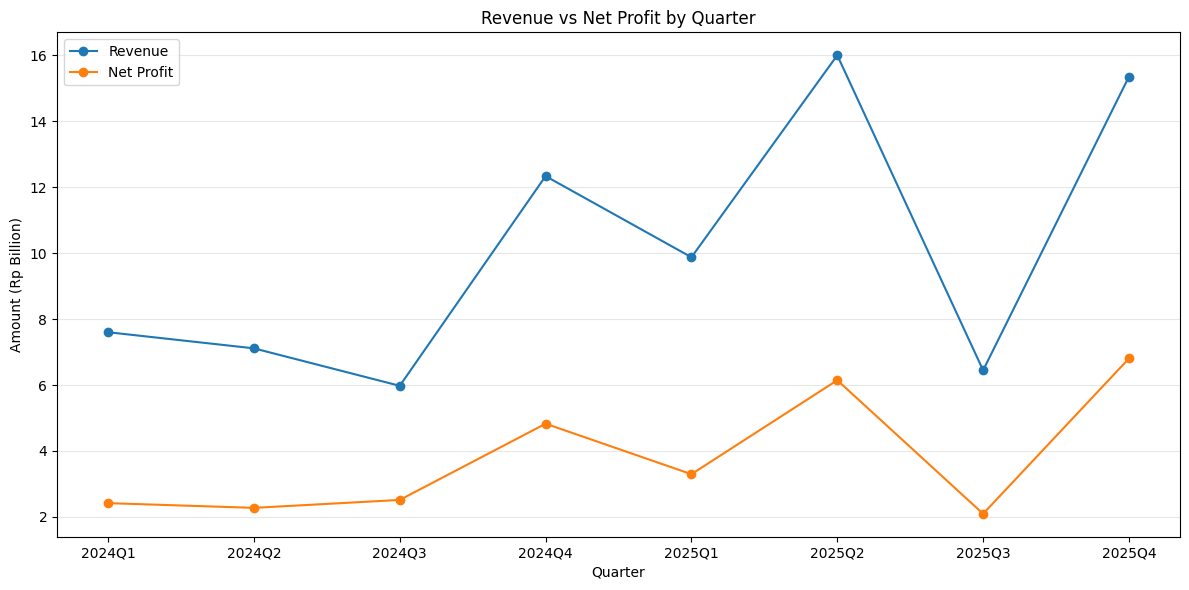

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    quarterly["quarter"],
    quarterly["revenue"] / 1e9,
    marker="o",
    label="Revenue"
)

plt.plot(
    quarterly["quarter"],
    quarterly["net_profit"] / 1e9,
    marker="o",
    label="Net Profit"
)

plt.title("Revenue vs Net Profit by Quarter")
plt.xlabel("Quarter")
plt.ylabel("Amount (Rp Billion)")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

The chart shows a significant decline in revenue and net profit in Q3 2025. Net profit fell by 65.94% compared with Q2 2025, indicating that the profitability decline was strongly linked to lower business scale. Management should investigate the causes of the revenue decline before attributing the problem to costs or discounts.

## **Chart 2 — Net Profit Change by Quarter**


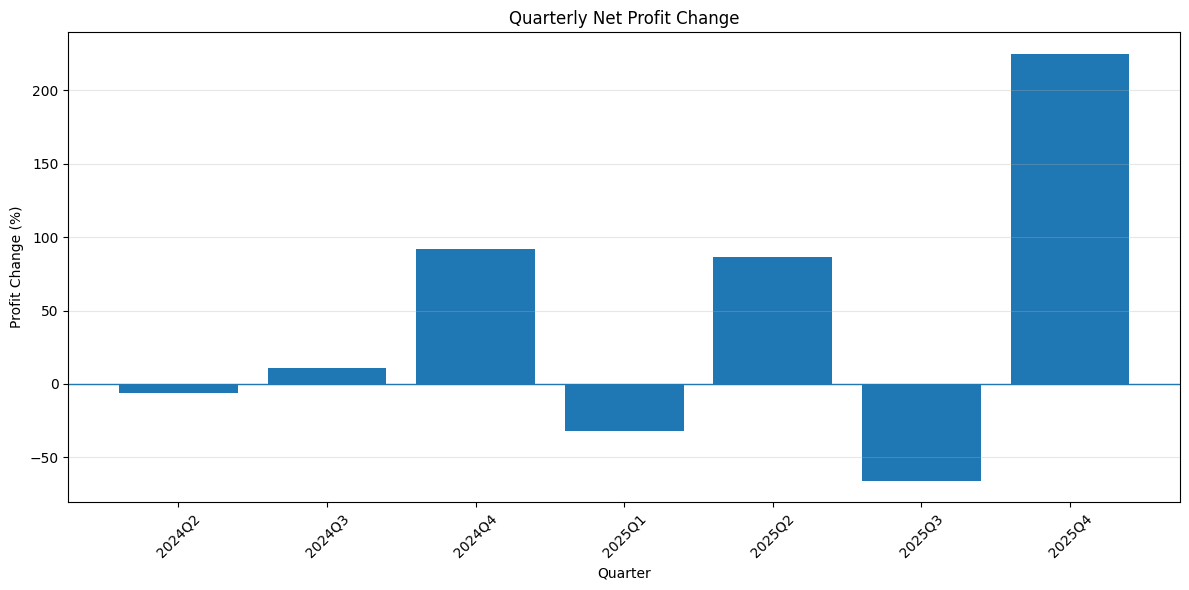

In [ ]:
plt.figure(figsize=(12, 6))

profit_change = quarterly.dropna(subset=["profit_change"])

plt.bar(
    profit_change["quarter"],
    profit_change["profit_change"]
)

plt.axhline(0, linewidth=1)

plt.title("Quarterly Net Profit Change")
plt.xlabel("Quarter")
plt.ylabel("Profit Change (%)")

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

This chart clearly shows:

1. 2024Q2 → -5.93%
2. 2025Q1 → -31.73%
3. 2025Q3 → -65.94%

Q3 2025 recorded the largest quarterly net profit decline at 65.94%, significantly exceeding previous negative movements. This makes Q3 the key period for identifying the operational and commercial drivers of the profitability deterioration.

## **Chart 3 — Profit Decline by Category**


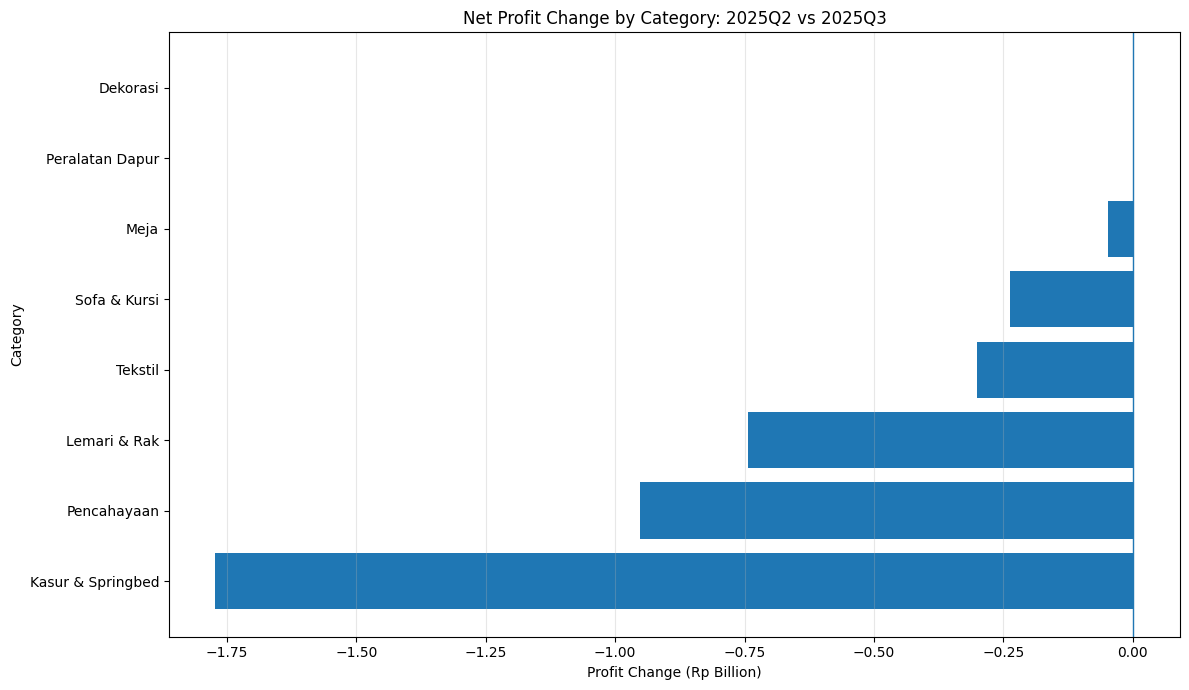

In [ ]:
plt.figure(figsize=(12, 7))

category_chart = category_pivot.sort_values("profit_change")

plt.barh(
    category_chart["category"],
    category_chart["profit_change"] / 1e9
)

plt.axvline(0, linewidth=1)

plt.title("Net Profit Change by Category: 2025Q2 vs 2025Q3")
plt.xlabel("Profit Change (Rp Billion)")
plt.ylabel("Category")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

This clearly shows:

1. Kasur & Springbed → -Rp1.77B
2. Pencahayaan → -Rp952M
3. Lemari & Rak → -Rp744M

Kasur & Springbed, Pencahayaan, and Lemari & Rak accounted for approximately 85.6% of the total profit decline. Management should prioritize these three categories because improvements in their pricing, product mix, cost structure, or promotional strategy could potentially recover a substantial portion of the lost profitability.

## **Chart 4 — Online Profit Margin by Quarter**

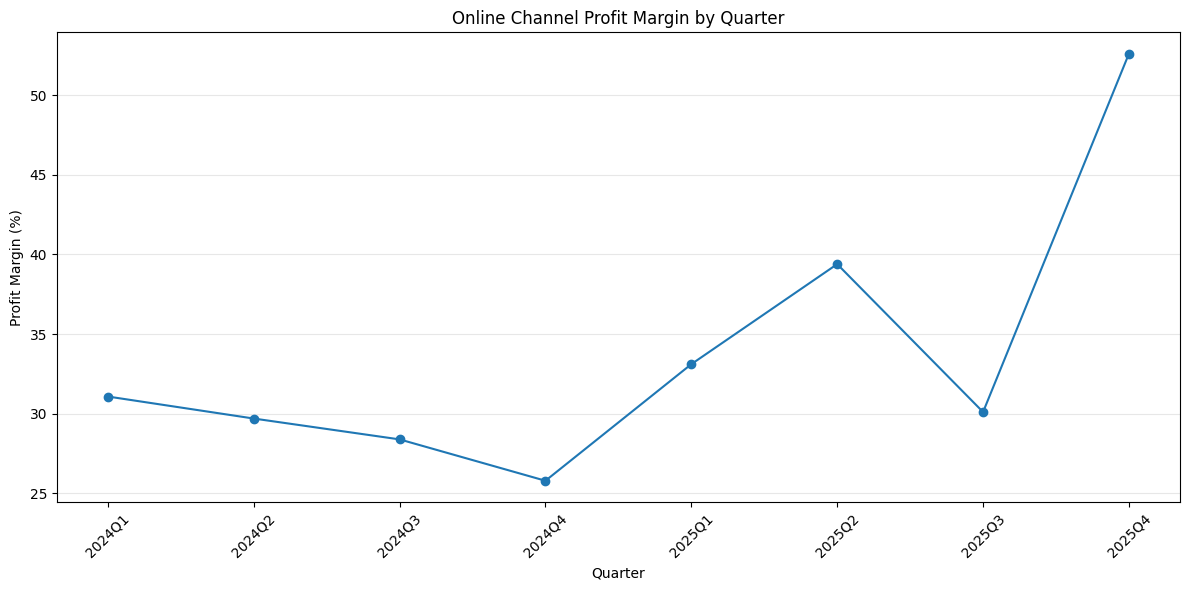

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    online_analysis["quarter"],
    online_analysis["profit_margin"],
    marker="o"
)

plt.title("Online Channel Profit Margin by Quarter")
plt.xlabel("Quarter")
plt.ylabel("Profit Margin (%)")

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

This chart shows that the Online segment remains profitable, but:

1. 2025Q2 → 39.39%
2. 2025Q3 → 30.11%

The Online channel remained profitable, but its profit margin declined from 39.39% to 30.11%. This represents a decline of approximately 9.28 percentage points. Therefore, the appropriate strategy is not to eliminate Online sales, but to identify the specific components driving the margin deterioration, particularly shipping costs, discounts, product mix, and transaction-level profitability.

## **Chart 5 — Average Discount vs Profit Margin by Quarter**

Objective: To examine the relationship between average discount and profit margin over time.

,quarter,avg_discount,revenue,net_profit,profit_margin
0,2024Q1,8.986874,7.601812e+09,2.417274e+09,31.798658
1,2024Q2,8.772369,7.113028e+09,2.274002e+09,31.969540
2,2024Q3,8.617021,5.976164e+09,2.514282e+09,42.071849
3,2024Q4,15.000000,1.233737e+10,4.826900e+09,39.124212
4,2025Q1,8.337492,9.876061e+09,3.295464e+09,33.368206
5,2025Q2,8.194047,1.600391e+10,6.146552e+09,38.406571
6,2025Q3,8.741059,6.446914e+09,2.093812e+09,32.477743
7,2025Q4,20.254745,1.535539e+10,6.805525e+09,44.320110


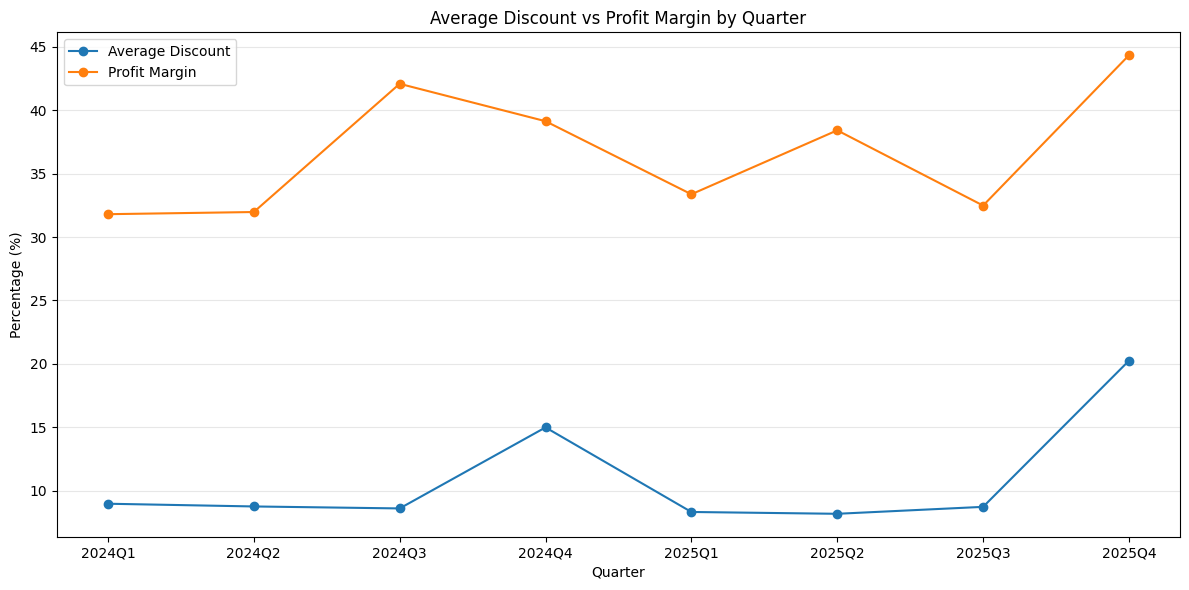

In [ ]:
# Prepare data for Chart 5

discount_margin = (
    transaction_sales
    .groupby("quarter")
    .agg(
        avg_discount=("discount_pct", "mean"),
        revenue=("revenue", "sum"),
        net_profit=("net_profit", "sum")
    )
    .reset_index()
)

discount_margin["profit_margin"] = (
    discount_margin["net_profit"] /
    discount_margin["revenue"] * 100
)

display(discount_margin)

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    discount_margin["quarter"],
    discount_margin["avg_discount"],
    marker="o",
    label="Average Discount"
)

plt.plot(
    discount_margin["quarter"],
    discount_margin["profit_margin"],
    marker="o",
    label="Profit Margin"
)

plt.title("Average Discount vs Profit Margin by Quarter")
plt.xlabel("Quarter")
plt.ylabel("Percentage (%)")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

Average discount increased by 0.55 percentage points from Q2 to Q3 2025, while profit margin decreased by 5.93 percentage points. This indicates potential margin pressure from increased discounting. However, discounting cannot be considered the primary cause based on this analysis alone because revenue contraction was substantially larger and appears to be a major contributor to the decline in absolute profit.

# **LIMITATIONS**

The analysis provides strong descriptive and diagnostic evidence but has several limitations. Missing store IDs limit store-level analysis, imputed costs introduce estimation uncertainty, shipping outliers may represent legitimate transactions, and operating expenses outside product and shipping costs are not included. Therefore, the calculated net profit should be interpreted as transaction-level profit rather than complete company-level net income.

# **CONCLUSION**

The analysis identifies Q3 2025 as the critical period of profitability deterioration. Net profit declined by 65.94%, accompanied by a 59.72% decline in revenue and a 5.93 percentage-point reduction in profit margin.

The decline was highly concentrated across three categories—Kasur & Springbed, Pencahayaan, and Lemari & Rak—which together contributed approximately 85.6% of the total profit decline. This suggests that targeted category-level intervention may be more effective than broad cost-cutting measures.

The Online channel remained profitable after shipping costs, although its margin declined from 39.39% to 30.11%. Therefore, the channel should be optimized rather than reduced.

Finally, average discount increased while profit margin declined, indicating potential margin pressure. However, the analysis does not establish causality. The most appropriate strategy is to focus on the affected categories, optimize Online economics, and implement targeted discounting while protecting sales volume.

